# Fiedler vector & tree partition — cached Kingman samples by $\eta$

For each cached imbalance bin $\eta \in \{1, 5, 10, 15\}$ (Kingman tree, $n=500$, $L=10{,}000$, $\mu=0.1$), show:
- **Left:** the Kingman tree (rectangular dendrogram on patristic distances).
- **Right:** the Fiedler value of each leaf, plotted at the **same vertical position as the leaf on the tree** (X = Fiedler value, Y aligned with tree leaves). Orange = positive (partition $+$), blue = negative (partition $-$).

Each cache entry now contains `M.npz`, `fiedler_ref.npz`, `partition.npz`, `tree.txt` (Newick), and `metadata.json`. The Newick is the actual tree used at sample time — needed because `np.random.seed` does **not** make dendropy's Kingman generator deterministic, so seeds alone can't reproduce the tree downstream.

In [28]:
import sys
from pathlib import Path

import numpy as np
import dendropy
import matplotlib.pyplot as plt
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform

# Render inline figures as vector (SVG) for crisp tree lines
get_ipython().run_line_magic("config", "InlineBackend.figure_format = 'svg'")

_ROOT = Path.cwd()
while _ROOT.parent != _ROOT and not (_ROOT / "setup.py").exists():
    _ROOT = _ROOT.parent
_PROJECT_ROOT = _ROOT / "sub_sampled_fielder_vec"
if str(_PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(_PROJECT_ROOT))

from src.utils.eta_pool_cache import param_key, load_pool_entry, list_completed_samples
from src.models.tree_models import get_tree_factory
from analysis.theoretical_interpretation.utils.linalg_features import (
    coherence_mu, compute_top_eigenpairs,
)

In [29]:
N           = 500
N_VALUES    = [500, 1000, 2000, 4000]   # for the coherence-vs-eta panel
SEQ_LEN     = 10_000
MU          = 0.1
POP_SIZE    = 1.0
TREE_MODEL  = "kingman"
SEQ_MODEL   = "JC69"
ETAS        = [1, 5, 10, 15]
SAMPLE_IDX  = 1

COLOR_POS = "#d97706"  # orange  (Fiedler > 0)
COLOR_NEG = "#1d4ed8"  # blue    (Fiedler < 0)

KEY = param_key(
    n=N, seq_len=SEQ_LEN, mu=MU,
    tree_model=TREE_MODEL, pop_size=POP_SIZE, seq_model=SEQ_MODEL,
)
print("param_key:", KEY)

FIG_DIR = _PROJECT_ROOT / "analysis" / "theoretical_interpretation" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

param_key: n0500_L10000_mu0p1000_kingman_pop1p0000_JC69


In [30]:
def load_sample(eta_target, idx=SAMPLE_IDX):
    res = load_pool_entry(_PROJECT_ROOT / "cache", KEY, eta_target, idx)
    if res is None:
        raise FileNotFoundError(f"Missing cached sample: eta={eta_target} idx={idx}")
    M, v_pop, partition, tree_newick, meta = res
    # Legacy fallback: partition not stored before the partition-persist change.
    if partition is None:
        partition = (v_pop > 0).astype(bool)
    return M, v_pop, partition, tree_newick, meta


def load_tree(tree_newick, meta):
    """Prefer the on-disk Newick (deterministic). Falls back to seed-based
    regeneration ONLY for legacy samples — note that np.random.seed does not
    actually make dendropy's Kingman generator deterministic, so the fallback
    tree will likely NOT match the one used at sample time."""
    if tree_newick is not None:
        return dendropy.Tree.get(data=tree_newick, schema="newick")
    np.random.seed(int(meta["seed"]))
    factory = get_tree_factory(meta["tree_model"], {
        "num_taxa": int(meta["n"]),
        "pop_size": float(meta["pop_size"]),
    })
    return factory()


def patristic_distance_matrix(tree):
    leaf_taxa = [leaf.taxon for leaf in tree.leaf_node_iter()]
    n = len(leaf_taxa)
    pdm = tree.phylogenetic_distance_matrix()
    D = np.zeros((n, n))
    for i in range(n):
        for j in range(i + 1, n):
            d = pdm.distance(leaf_taxa[i], leaf_taxa[j])
            D[i, j] = D[j, i] = d
    return D, leaf_taxa

In [31]:
samples = {}
for eta in ETAS:
    M, v_pop, partition, tree_newick, meta = load_sample(eta)
    tree = load_tree(tree_newick, meta)
    leaves = list(tree.leaf_node_iter())
    assert len(leaves) == M.shape[0], (
        f"tree leaves={len(leaves)} but M.shape[0]={M.shape[0]} (seed={meta['seed']})"
    )
    samples[eta] = {
        "M": M, "v_pop": v_pop, "partition": partition,
        "meta": meta, "tree": tree,
        "tree_source": "disk-newick" if tree_newick is not None else "seed-regen (legacy)",
    }
    print(f"eta_target={eta:>2d}  realized eta={meta['eta']:.3f}  "
          f"n1={meta['n1']}  n2={meta['n2']}  seed={meta['seed']}  "
          f"part+={int(partition.sum())}  tree={samples[eta]['tree_source']}")

eta_target= 1  realized eta=1.463  n1=297  n2=203  seed=1  part+=297  tree=disk-newick
eta_target= 5  realized eta=4.435  n1=92  n2=408  seed=3  part+=92  tree=disk-newick
eta_target=10  realized eta=10.628  n1=43  n2=457  seed=10  part+=43  tree=disk-newick
eta_target=15  realized eta=15.129  n1=31  n2=469  seed=71  part+=31  tree=disk-newick


In [32]:
from src.utils.partition_validity import check_partition_valid_in_tree


for eta, s in samples.items():
    valid = check_partition_valid_in_tree(s["tree"], s["partition"])
    s["valid"] = bool(valid)
    print(f"eta={s['meta']['eta']:.2f}  (target {eta:>2d})  "
          f"n1={s['meta']['n1']}, n2={s['meta']['n2']}  "
          f"-> single-edge cut: {s['valid']}")

eta=1.46  (target  1)  n1=297, n2=203  -> single-edge cut: True
eta=4.43  (target  5)  n1=92, n2=408  -> single-edge cut: True
eta=10.63  (target 10)  n1=43, n2=457  -> single-edge cut: True
eta=15.13  (target 15)  n1=31, n2=469  -> single-edge cut: True


In [33]:
def plot_row(ax_tree, ax_fiedler, v_pop, partition, meta, tree, valid):
    n = v_pop.shape[0]

    # ---- Left: rectangular dendrogram on patristic distances ----
    D, _ = patristic_distance_matrix(tree)
    Z = hierarchy.linkage(squareform(D, checks=False), method="average")
    dendro = hierarchy.dendrogram(
        Z, ax=ax_tree, orientation="left", no_labels=True,
        color_threshold=0, above_threshold_color="#262626",
    )
    leaf_order = dendro["leaves"]            # indices into v_pop, in tree-tip order (bottom -> top)
    ax_tree.set_yticks([])
    for s in ax_tree.spines.values():
        s.set_visible(False)
    ax_tree.set_xticks([])

    # ---- Right: Fiedler scatter sharing the tree's vertical leaf axis ----
    y_pos = np.arange(n) * 10 + 5
    v_in_tree_order = v_pop[leaf_order]
    part_in_tree_order = partition[leaf_order]
    colors = [COLOR_POS if p else COLOR_NEG for p in part_in_tree_order]
    ax_fiedler.scatter(
        v_in_tree_order, y_pos,
        s=22, c=colors, linewidths=0, alpha=0.85,
    )
    ax_fiedler.axvline(0, color="#9ca3af", lw=0.5)
    ax_fiedler.set_ylim(0, 10 * n)
    ax_fiedler.set_yticks([])
    ax_fiedler.set_xlabel("Fiedler Value")

    for s in ("top", "right"):
        ax_fiedler.spines[s].set_visible(False)

Saved -> /Users/itayg/PythonRepo/spectral-tree-inference/sub_sampled_fielder_vec/analysis/theoretical_interpretation/figures/fiedler_tree_partition_eta01.png/.pdf/.svg


/var/folders/k6/8drtl2312g793lb2vy4c83gc0000gn/T/ipykernel_11738/4068716250.py:10: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


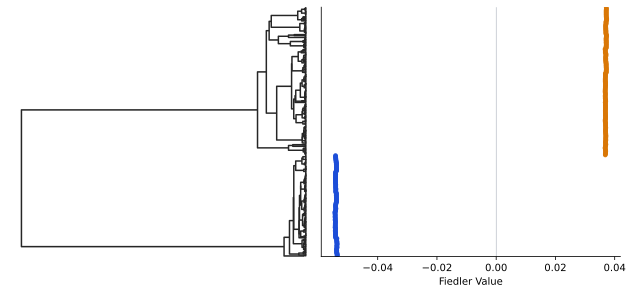

Saved -> /Users/itayg/PythonRepo/spectral-tree-inference/sub_sampled_fielder_vec/analysis/theoretical_interpretation/figures/fiedler_tree_partition_eta05.png/.pdf/.svg


/var/folders/k6/8drtl2312g793lb2vy4c83gc0000gn/T/ipykernel_11738/4068716250.py:10: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


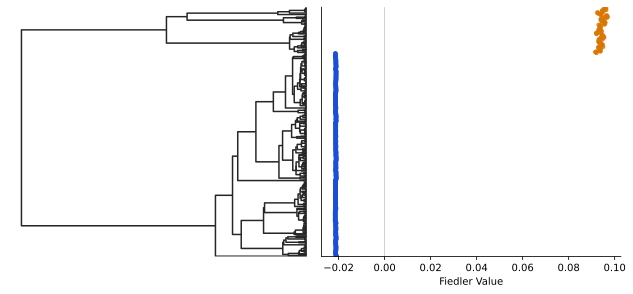

Saved -> /Users/itayg/PythonRepo/spectral-tree-inference/sub_sampled_fielder_vec/analysis/theoretical_interpretation/figures/fiedler_tree_partition_eta10.png/.pdf/.svg


/var/folders/k6/8drtl2312g793lb2vy4c83gc0000gn/T/ipykernel_11738/4068716250.py:10: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


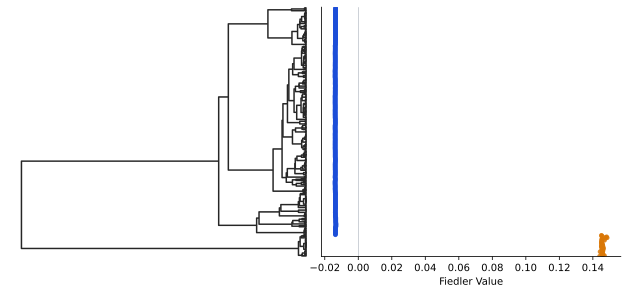

Saved -> /Users/itayg/PythonRepo/spectral-tree-inference/sub_sampled_fielder_vec/analysis/theoretical_interpretation/figures/fiedler_tree_partition_eta15.png/.pdf/.svg


/var/folders/k6/8drtl2312g793lb2vy4c83gc0000gn/T/ipykernel_11738/4068716250.py:10: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


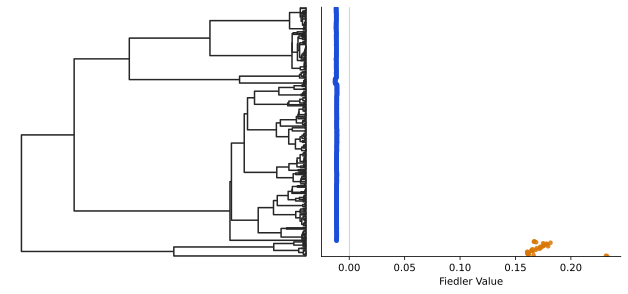

In [34]:
for eta in ETAS:
    s = samples[eta]
    fig, (ax_tree, ax_fiedler) = plt.subplots(
        1, 2,
        figsize=(11, 4.5),
        gridspec_kw={"width_ratios": [1.0, 1.0], "wspace": 0.05},
    )
    plot_row(ax_tree, ax_fiedler, s["v_pop"], s["partition"],
             s["meta"], s["tree"], s["valid"])
    fig.tight_layout()

    out_base = FIG_DIR / f"fiedler_tree_partition_eta{eta:02d}"
    fig.savefig(out_base.with_suffix(".png"), dpi=200, bbox_inches="tight")
    fig.savefig(out_base.with_suffix(".pdf"), bbox_inches="tight")
    fig.savefig(out_base.with_suffix(".svg"), bbox_inches="tight")
    print(f"Saved -> {out_base}.png/.pdf/.svg")
    plt.show()

# Coherence vs. imbalance — full pool

Empirical subspace coherence $\mu(U) = (n/2)\,\max_i \|e_i^\top U\|^2$ for the top-2 Laplacian eigenvectors of every cached sample (all $\eta$ bins, not just `SAMPLE_IDX`), compared against the V.03 identity $\mu(U) = (1+\eta)/2$.

In [35]:
from scipy.linalg import eigh as _eigh_partial

records = []
for n in N_VALUES:
    key = param_key(
        n=n, seq_len=SEQ_LEN, mu=MU,
        tree_model=TREE_MODEL, pop_size=POP_SIZE, seq_model=SEQ_MODEL,
    )
    for eta in ETAS:
        indices = list_completed_samples(_PROJECT_ROOT / "cache", key, eta)
        for idx in indices:
            res = load_pool_entry(_PROJECT_ROOT / "cache", key, eta, idx)
            if res is None:
                continue
            M, _v_pop, _part, _newick, meta = res
            L = np.diag(M.sum(axis=1)) - M
            # partial eigh: only the 3 smallest pairs (much faster at large n)
            eigvals, eigvecs = _eigh_partial(L, subset_by_index=[0, 2])
            mu_emp = coherence_mu(eigvecs[:, :2])
            records.append({
                "n":          int(n),
                "eta_target": int(eta),
                "eta":        float(meta["eta"]),
                "mu_emp":     float(mu_emp),
                "n1":         int(meta["n1"]),
                "n2":         int(meta["n2"]),
            })

print(f"loaded {len(records)} samples")
for n in N_VALUES:
    counts = [sum(1 for r in records if r["n"] == n and r["eta_target"] == eta) for eta in ETAS]
    print(f"  n={n:>5d}  " + "  ".join(f"eta={e:>2d}:k={c:>2d}" for e, c in zip(ETAS, counts)))

loaded 231 samples
  n=  500  eta= 1:k=20  eta= 5:k=20  eta=10:k=20  eta=15:k=20
  n= 1000  eta= 1:k=10  eta= 5:k=10  eta=10:k=10  eta=15:k=10
  n= 2000  eta= 1:k=10  eta= 5:k=10  eta=10:k=10  eta=15:k=10
  n= 4000  eta= 1:k=20  eta= 5:k=20  eta=10:k=20  eta=15:k=11


Saved -> /Users/itayg/PythonRepo/spectral-tree-inference/sub_sampled_fielder_vec/analysis/theoretical_interpretation/figures/coherence_vs_eta.png/.pdf/.svg


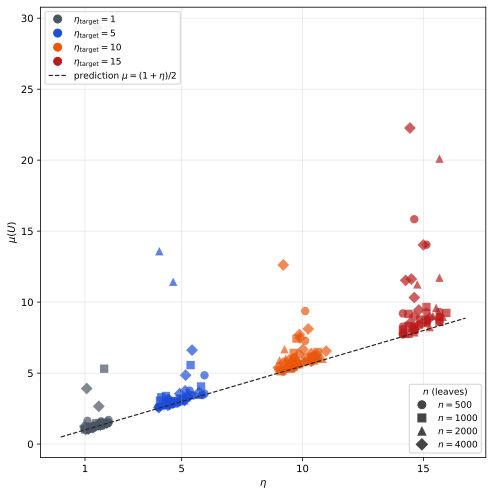

In [36]:
from matplotlib.lines import Line2D

ETA_COLORS = {1: "#4b5563", 5: "#1d4ed8", 10: "#ea580c", 15: "#b91c1c"}
N_MARKERS  = {500: "o", 1000: "s", 2000: "^", 4000: "D"}

etas_arr = np.array([r["eta"]        for r in records])
mu_arr   = np.array([r["mu_emp"]     for r in records])
bin_arr  = np.array([r["eta_target"] for r in records])
n_arr    = np.array([r["n"]          for r in records])

fig, ax = plt.subplots(figsize=(7, 7))
for n in N_VALUES:
    for eta_t in ETAS:
        mask = (n_arr == n) & (bin_arr == eta_t)
        if not mask.any():
            continue
        ax.scatter(
            etas_arr[mask], mu_arr[mask],
            marker=N_MARKERS[n], s=70,
            color=ETA_COLORS[eta_t], alpha=0.7, linewidths=0,
        )

eta_grid = np.linspace(0, max(float(etas_arr.max()), float(max(ETAS))) * 1.05, 200)
ax.plot(
    eta_grid, (1.0 + eta_grid) / 2.0,
    ls="--", color="#262626", lw=1.2,
)

ax.set_xlabel(r"$\eta$")
ax.set_ylabel(r"$\mu(U)$")
ax.set_xticks(ETAS)
ax.grid(True, alpha=0.3)

# Two legends: eta (color) on the left, n (shape) on the right
eta_handles = [
    Line2D([0], [0], marker="o", linestyle="", color=ETA_COLORS[e],
           markersize=8, label=fr"$\eta_{{\mathrm{{target}}}}={e}$")
    for e in ETAS
]
pred_handle = Line2D([0], [0], ls="--", color="#262626", lw=1.2,
                     label=r"prediction $\mu = (1+\eta)/2$")
n_handles = [
    Line2D([0], [0], marker=N_MARKERS[n], linestyle="", color="#444444",
           markersize=8, label=fr"$n={n}$")
    for n in N_VALUES
]

leg1 = ax.legend(handles=eta_handles + [pred_handle],
                 loc="upper left", fontsize=9, framealpha=0.9)
ax.add_artist(leg1)
ax.legend(handles=n_handles, loc="lower right", fontsize=9,
          framealpha=0.9, title=r"$n$ (leaves)", title_fontsize=9)

fig.tight_layout()

out_base = FIG_DIR / "coherence_vs_eta"
fig.savefig(out_base.with_suffix(".png"), dpi=200, bbox_inches="tight")
fig.savefig(out_base.with_suffix(".pdf"), bbox_inches="tight")
fig.savefig(out_base.with_suffix(".svg"), bbox_inches="tight")
print(f"Saved -> {out_base}.png/.pdf/.svg")
plt.show()

Saved -> /Users/itayg/PythonRepo/spectral-tree-inference/sub_sampled_fielder_vec/analysis/theoretical_interpretation/figures/coherence_vs_eta_by_n.png/.pdf/.svg


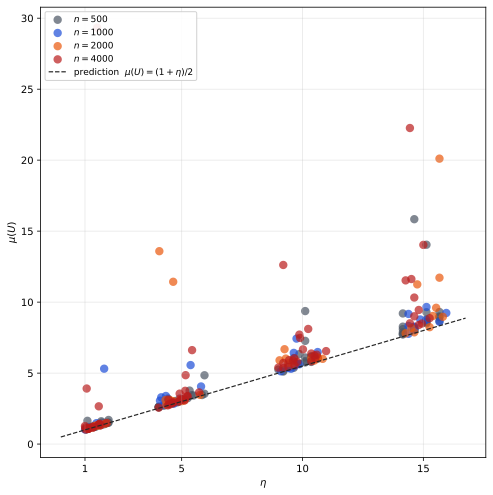

In [38]:
N_COLORS = {500: "#4b5563", 1000: "#1d4ed8", 2000: "#ea580c", 4000: "#b91c1c"}

etas_arr = np.array([r["eta"]    for r in records])
mu_arr   = np.array([r["mu_emp"] for r in records])
n_arr    = np.array([r["n"]      for r in records])

fig, ax = plt.subplots(figsize=(7, 7))
for n in N_VALUES:
    mask = n_arr == n
    if not mask.any():
        continue
    ax.scatter(
        etas_arr[mask], mu_arr[mask],
        s=70, color=N_COLORS[n], alpha=0.7, linewidths=0,
        label=fr"$n={n}$",
    )

eta_grid = np.linspace(0, max(float(etas_arr.max()), float(max(ETAS))) * 1.05, 200)
ax.plot(
    eta_grid, (1.0 + eta_grid) / 2.0,
    ls="--", color="#262626", lw=1.2,
    label=r"prediction  $\mu(U) = (1+\eta)/2$",
)

ax.set_xlabel(r"$\eta$")
ax.set_ylabel(r"$\mu(U)$")
ax.set_xticks(ETAS)
ax.grid(True, alpha=0.3)
ax.legend(loc="upper left", fontsize=9, framealpha=0.9)
fig.tight_layout()

out_base = FIG_DIR / "coherence_vs_eta_by_n"
fig.savefig(out_base.with_suffix(".png"), dpi=200, bbox_inches="tight")
fig.savefig(out_base.with_suffix(".pdf"), bbox_inches="tight")
fig.savefig(out_base.with_suffix(".svg"), bbox_inches="tight")
print(f"Saved -> {out_base}.png/.pdf/.svg")
plt.show()

# Validate the two lower bounds on $\eta$

For the population-spectral process to succeed, the realized $\eta$ must clear two thresholds:

- **Data-driven (Lemma 0.4):** $\eta \ge \dfrac{\rho}{S_{\max}^{\,\text{out}}}$, computed per sample from the cached metadata $(\rho,\,S_{\max}^{\,\text{out}})$.
- **Asymptotic scaling:** $\eta = \Omega\!\left(\sqrt[3]{n/\log n}\right)$, a hidden-constant lower bound that depends only on $n$.

For each $\eta$-bin we report the mean realized $\eta$, the mean of the structural bound, and the fraction of samples clearing each.

In [37]:
asymp_lb = (N / np.log(N)) ** (1.0 / 3.0)
print(f"Asymptotic bound  (n / log n)^(1/3)  at n={N}:  {asymp_lb:.3f}\n")

header = (
    f"{'eta_t':>6} {'k':>4} "
    f"{'eta (mean)':>11} {'eta (min)':>10} "
    f"{'rho/S_out_max (mean)':>22} "
    f"{'>= struct':>10} {'>= asymp':>10}"
)
print(header)
print("-" * len(header))

for eta_t in ETAS:
    indices = list_completed_samples(_PROJECT_ROOT / "cache", KEY, eta_t)
    etas, struct_bounds = [], []
    for idx in indices:
        res = load_pool_entry(_PROJECT_ROOT / "cache", KEY, eta_t, idx)
        if res is None:
            continue
        *_, meta = res
        etas.append(float(meta["eta"]))
        struct_bounds.append(float(meta["rho"]) / float(meta["S_out_max"]))
    if not etas:
        continue
    etas = np.array(etas)
    struct_bounds = np.array(struct_bounds)
    pct_struct = 100.0 * float(np.mean(etas >= struct_bounds))
    pct_asymp  = 100.0 * float(np.mean(etas >= asymp_lb))
    print(
        f"{eta_t:>6d} {len(etas):>4d} "
        f"{etas.mean():>11.3f} {etas.min():>10.3f} "
        f"{struct_bounds.mean():>22.3f} "
        f"{pct_struct:>9.0f}% {pct_asymp:>9.0f}%"
    )

Asymptotic bound  (n / log n)^(1/3)  at n=500:  4.317

 eta_t    k  eta (mean)  eta (min)   rho/S_out_max (mean)  >= struct   >= asymp
-------------------------------------------------------------------------------
     1   20       1.488      1.033                 20.619        25%         0%
     5   20       4.854      4.051                  5.682        70%        75%
    10   20       9.937      9.000                 53.939        75%       100%
    15   20      14.817     14.152                  4.626        95%       100%
